In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/customer_churn.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.shape

(7043, 21)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop_duplicates()

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
20.05     8
19.55     7
45.3      7
19.45     6
20.25     6
20.15     6
20.45     5
20.3      5
19.4      4
75.3      4
44.4      4
19.3      4
19.85     4
20.5      4
70.6      4
Name: count, dtype: int64

In [10]:
df[df["TotalCharges"].str.strip() == " "][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn


In [11]:
blank_total = df[df["TotalCharges"].str.strip() == " "]

print("Blank TotalCharges rows:", len(blank_total))

Blank TotalCharges rows: 0


In [12]:
blank_total[[
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]].to_string(index=False)

'Empty DataFrame\nColumns: [customerID, tenure, MonthlyCharges, TotalCharges, Churn]\nIndex: []'

In [13]:
blank_total[["tenure", "MonthlyCharges", "Churn"]]

,tenure,MonthlyCharges,Churn


In [14]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [15]:
print(df["TotalCharges"].isna().sum())

11


In [16]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [17]:
df[df["TotalCharges"].isna()]["tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

In [18]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [19]:
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 0


In [20]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [21]:
df.to_csv("../data/processed/customer_churn_cleaned.csv", index=False)

In [22]:
import os

print(os.path.exists("../data/processed/customer_churn_cleaned.csv"))

True


In [23]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [24]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [25]:
retention_rate = (df["Churn"] == "No").mean() * 100

print(f"Overall Retention Rate: {retention_rate:.2f}%")

Overall Retention Rate: 73.46%


In [26]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [27]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Contract Churn Insight

Month-to-month customers have the highest churn rate at 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts. This indicates a strong association between contract duration and customer retention, with customers on longer-term contracts showing substantially lower churn.

In [28]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [29]:
bins = [0, 6, 12, 24, 48, 72]

labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [30]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

tenure_churn

Churn,No,Yes
TenureGroup,,
0-6 months,47.06,52.94
7-12 months,64.11,35.89
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


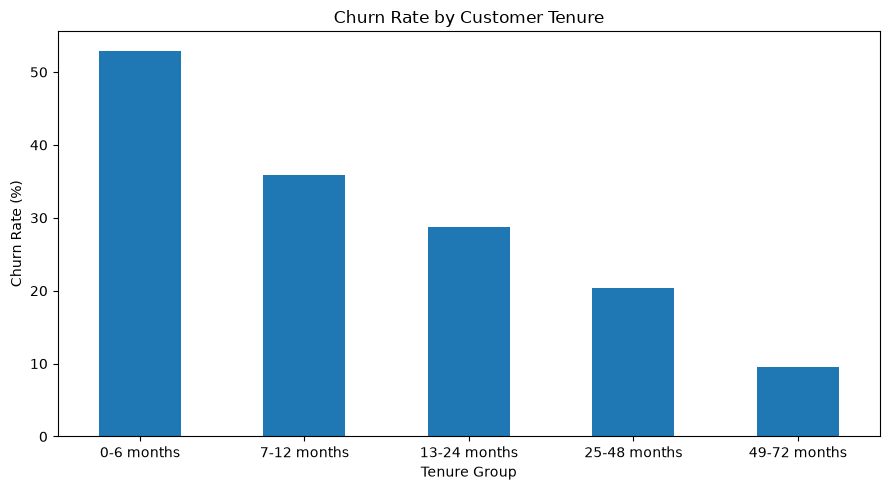

In [31]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean().round(2)

monthly_charges_churn

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

In [33]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

internet_churn

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

In [34]:
techsupport_churn = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

techsupport_churn

TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64

In [35]:
security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

security_churn

OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64

In [36]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

payment_churn

PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64

In [37]:
lifetime_charges = (
    df.groupby("Churn")["TotalCharges"]
      .mean()
      .round(2)
)

lifetime_charges

Churn
No     2549.91
Yes    1531.80
Name: TotalCharges, dtype: float64

In [38]:
tenure_by_churn = (
    df.groupby("Churn")["tenure"]
      .mean()
      .round(2)
)

tenure_by_churn

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

In [39]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

senior_churn

SeniorCitizen
0    23.61
1    41.68
Name: Churn, dtype: float64

In [40]:
partner_churn = (
    df.groupby("Partner")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

partner_churn

Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

In [41]:
dependents_churn = (
    df.groupby("Dependents")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

dependents_churn

Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

In [42]:
retention_summary = pd.DataFrame({
    "Factor": [
        "Month-to-month Contract",
        "0-6 Months Tenure",
        "Fiber Optic",
        "No Tech Support",
        "No Online Security",
        "Electronic Check",
        "Senior Citizen",
        "No Partner",
        "No Dependents"
    ],
    "Churn_Rate": [
        42.71,
        52.94,
        41.89,
        41.64,
        41.77,
        45.29,
        41.68,
        32.96,
        31.28
    ]
})

retention_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

,Factor,Churn_Rate
1,0-6 Months Tenure,52.94
5,Electronic Check,45.29
0,Month-to-month Contract,42.71
2,Fiber Optic,41.89
4,No Online Security,41.77
6,Senior Citizen,41.68
3,No Tech Support,41.64
7,No Partner,32.96
8,No Dependents,31.28


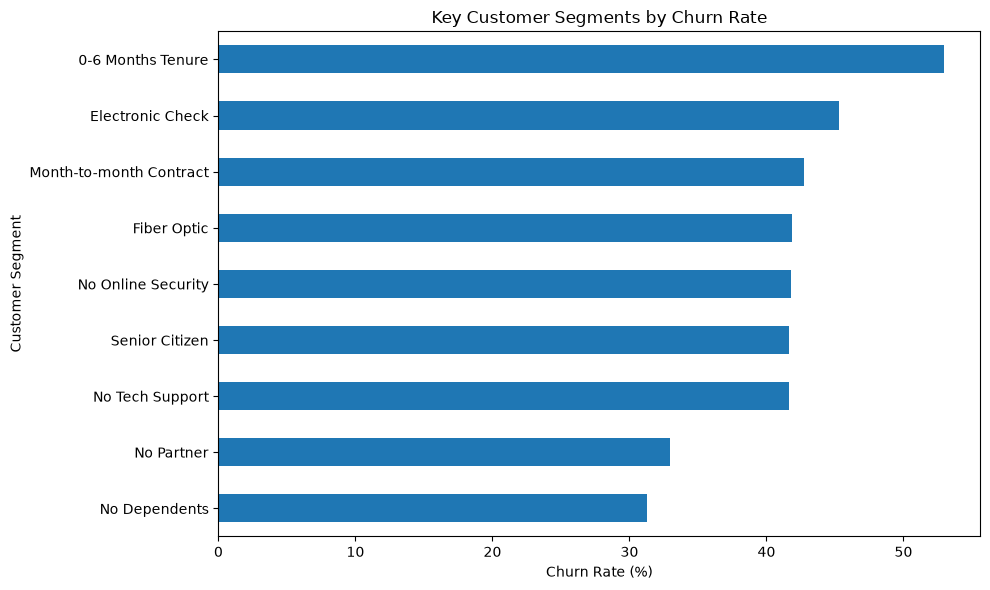

In [43]:
retention_summary_sorted = retention_summary.sort_values(
    "Churn_Rate",
    ascending=True
)

retention_summary_sorted.plot(
    x="Factor",
    y="Churn_Rate",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("Key Customer Segments by Churn Rate")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

In [44]:
key_findings = pd.DataFrame({
    "Finding": [
        "Overall Churn Rate",
        "Overall Retention Rate",
        "Highest Churn Tenure Group",
        "Highest Churn Payment Method",
        "Highest Churn Contract Type",
        "Highest Churn Internet Service",
        "No Tech Support Churn",
        "No Online Security Churn"
    ],
    "Result": [
        "26.54%",
        "73.46%",
        "0-6 months: 52.94%",
        "Electronic check: 45.29%",
        "Month-to-month: 42.71%",
        "Fiber optic: 41.89%",
        "41.64%",
        "41.77%"
    ]
})

key_findings

,Finding,Result
0,Overall Churn Rate,26.54%
1,Overall Retention Rate,73.46%
2,Highest Churn Tenure Group,0-6 months: 52.94%
3,Highest Churn Payment Method,Electronic check: 45.29%
4,Highest Churn Contract Type,Month-to-month: 42.71%
5,Highest Churn Internet Service,Fiber optic: 41.89%
6,No Tech Support Churn,41.64%
7,No Online Security Churn,41.77%


In [45]:
recommendations = pd.DataFrame({
    "Churn_Risk": [
        "0-6 months tenure",
        "Month-to-month contract",
        "Electronic check",
        "No Tech Support",
        "No Online Security",
        "Fiber optic"
    ],
    "Recommended_Action": [
        "Strengthen onboarding and early-stage customer engagement",
        "Encourage suitable customers to move to longer-term contracts",
        "Investigate payment experience and promote automatic payment options",
        "Promote technical support and improve support accessibility",
        "Promote online security services to relevant customers",
        "Investigate fiber customer pricing, service quality and support experience"
    ]
})

recommendations

,Churn_Risk,Recommended_Action
0,0-6 months tenure,Strengthen onboarding and early-stage customer...
1,Month-to-month contract,Encourage suitable customers to move to longer...
2,Electronic check,Investigate payment experience and promote aut...
3,No Tech Support,Promote technical support and improve support ...
4,No Online Security,Promote online security services to relevant c...
5,Fiber optic,"Investigate fiber customer pricing, service qu..."


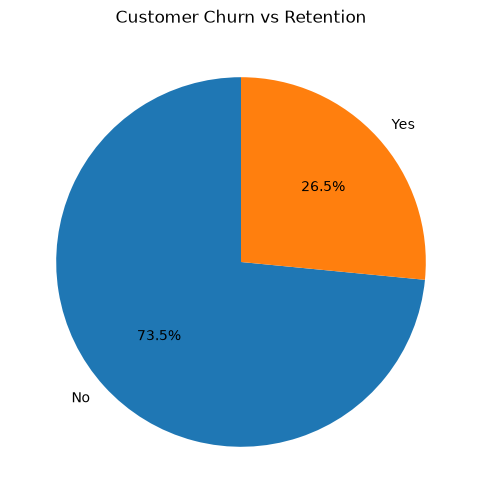

In [46]:
churn_counts = df["Churn"].value_counts()

churn_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6),
    startangle=90
)

plt.title("Customer Churn vs Retention")
plt.ylabel("")
plt.show()

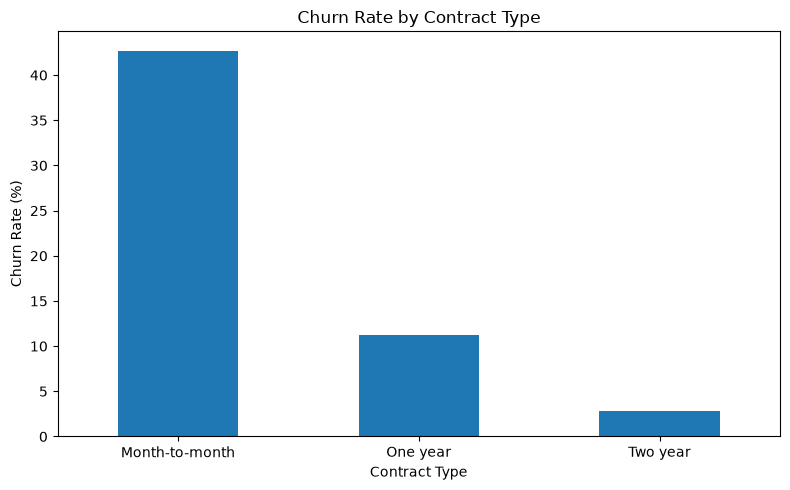

In [47]:
contract_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

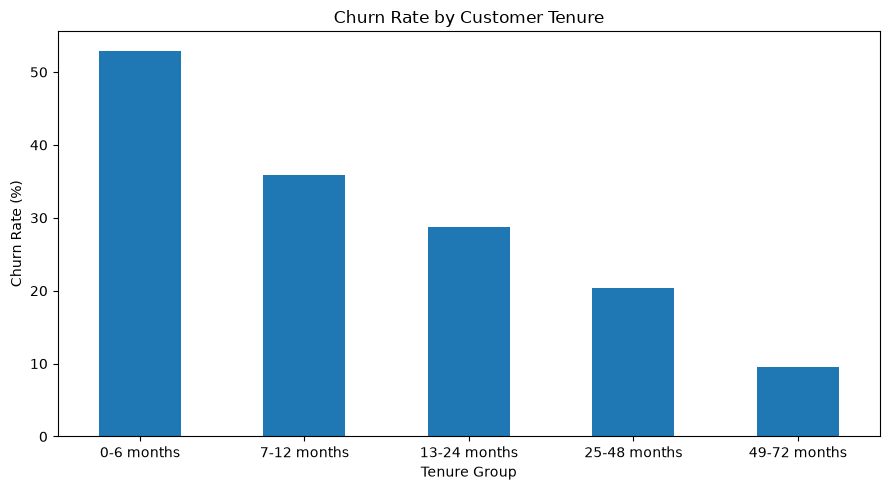

In [48]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

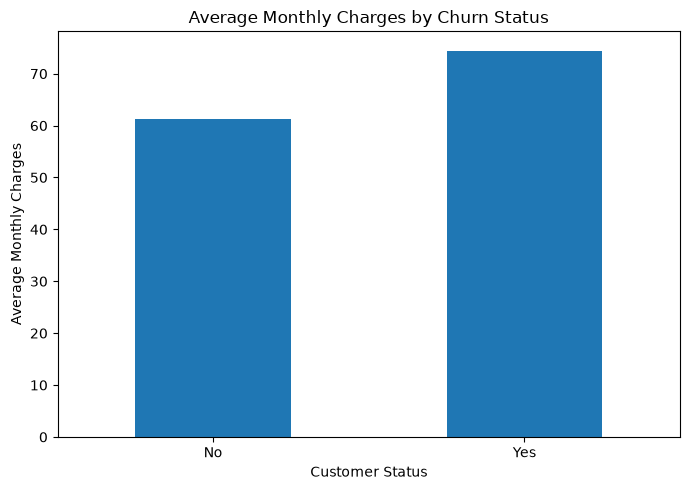

In [49]:
monthly_charges_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

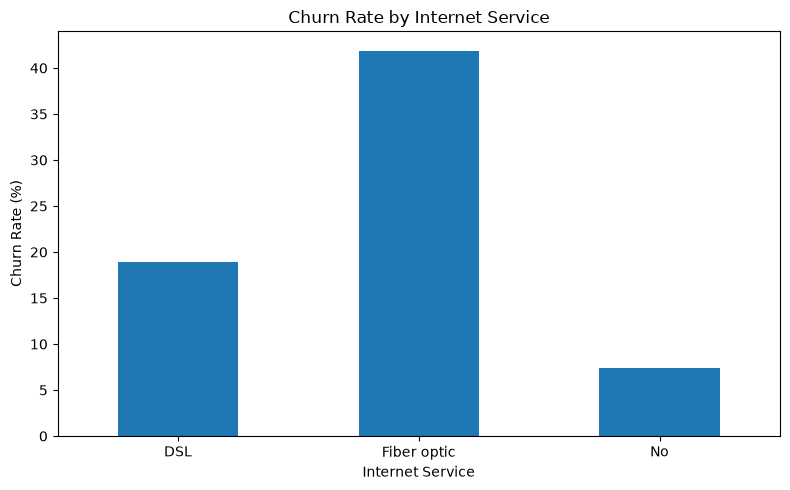

In [50]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

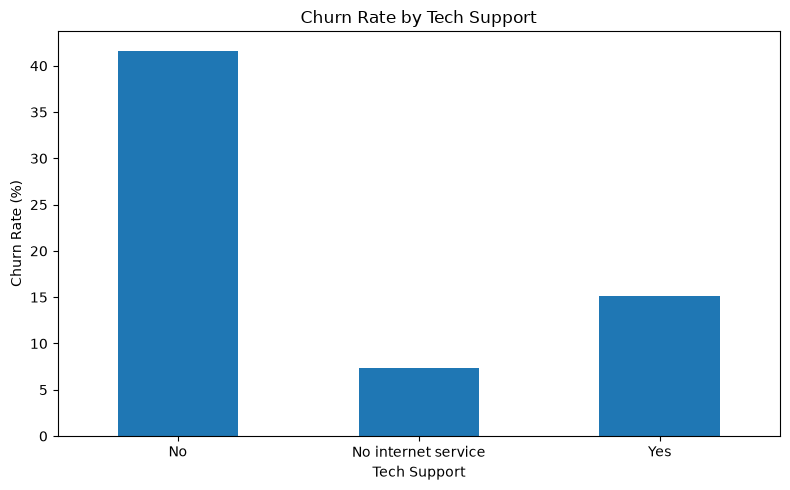

In [51]:
techsupport_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

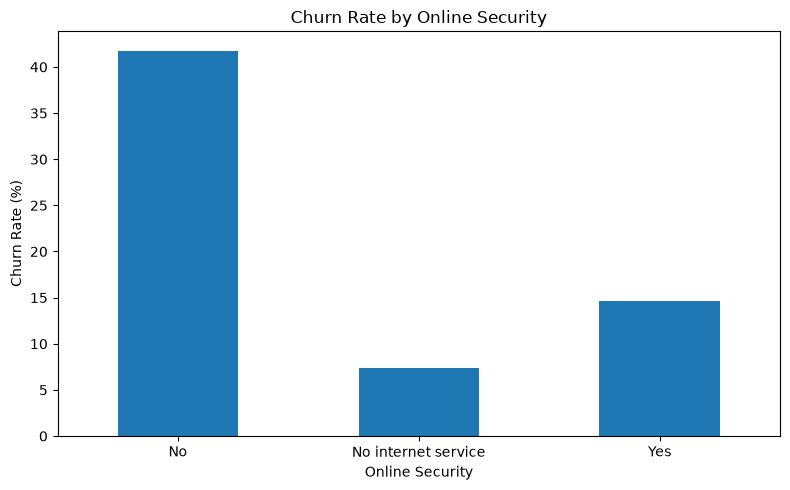

In [52]:
security_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

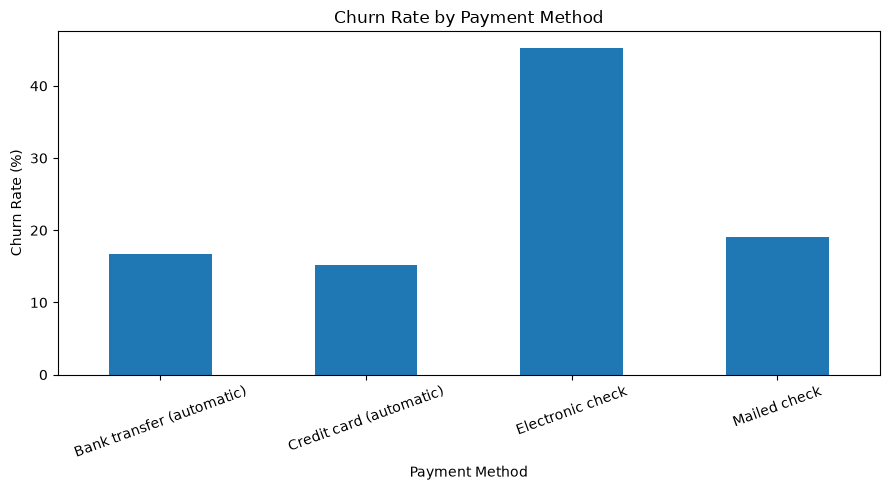

In [53]:
payment_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

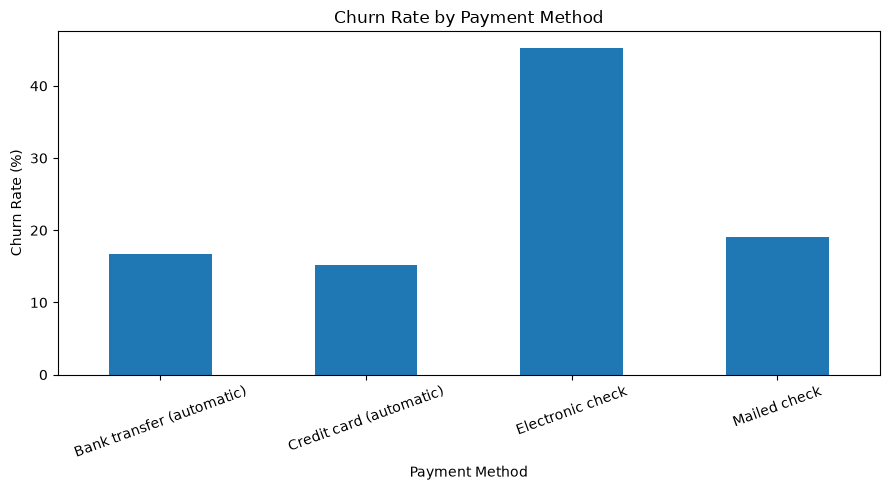

In [54]:
payment_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

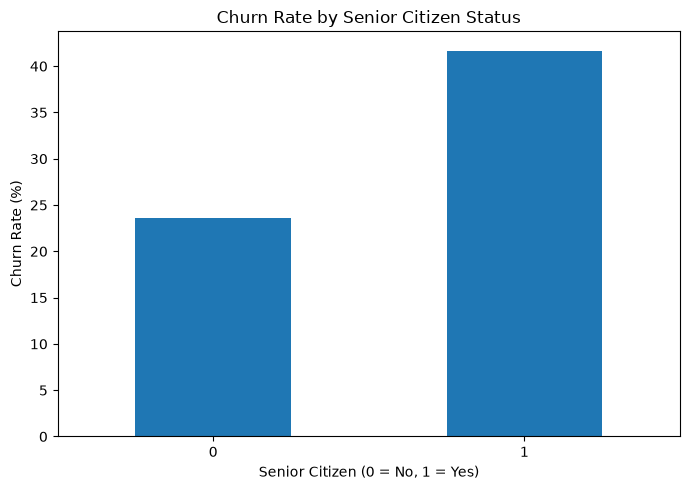

In [55]:
senior_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
total_customers = len(df)
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = (df["Churn"] == "Yes").mean() * 100
retention_rate = (df["Churn"] == "No").mean() * 100

print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")

Total Customers: 7,043
Churned Customers: 1,869
Churn Rate: 26.54%
Retention Rate: 73.46%


In [57]:
print("=" * 50)
print("CUSTOMER RETENTION & CHURN ANALYSIS")
print("=" * 50)

print(f"Total Customers      : {total_customers:,}")
print(f"Churned Customers     : {churned_customers:,}")
print(f"Overall Churn Rate    : {churn_rate:.2f}%")
print(f"Overall Retention    : {retention_rate:.2f}%")
print("=" * 50)

CUSTOMER RETENTION & CHURN ANALYSIS
Total Customers      : 7,043
Churned Customers     : 1,869
Overall Churn Rate    : 26.54%
Overall Retention    : 73.46%


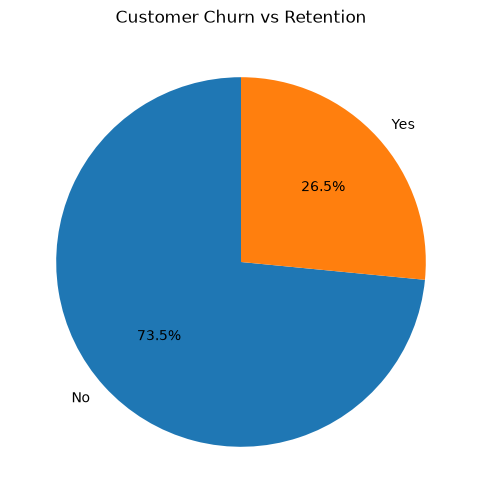

In [58]:
churn_counts = df["Churn"].value_counts()

churn_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6),
    startangle=90
)

plt.title("Customer Churn vs Retention")
plt.ylabel("")
plt.show()

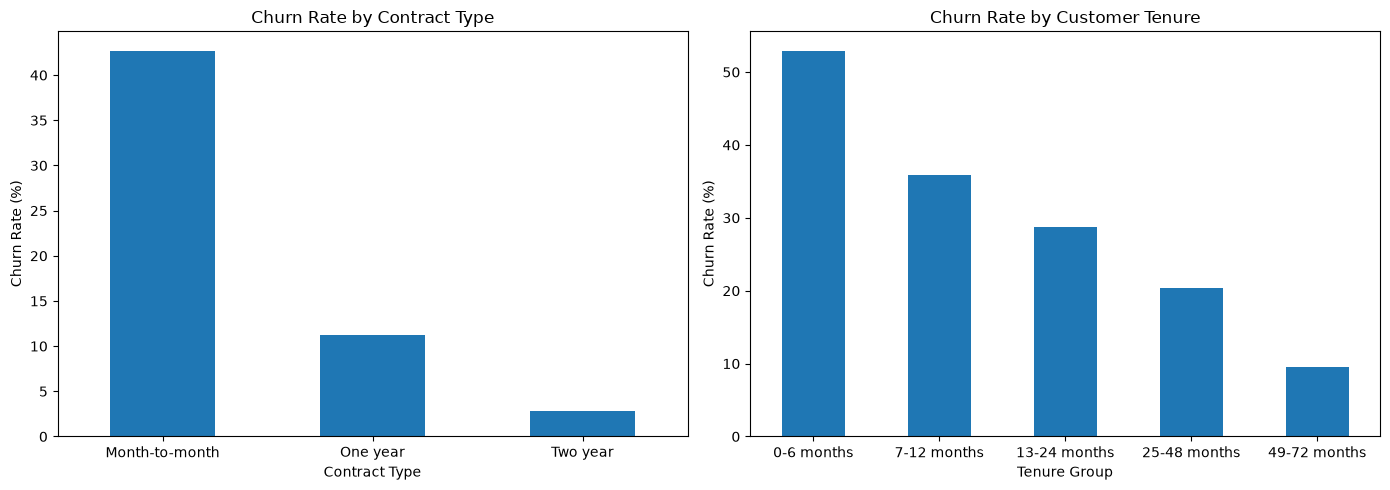

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_churn["Yes"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=0)

tenure_churn["Yes"].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Churn Rate by Customer Tenure")
axes[1].set_xlabel("Tenure Group")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

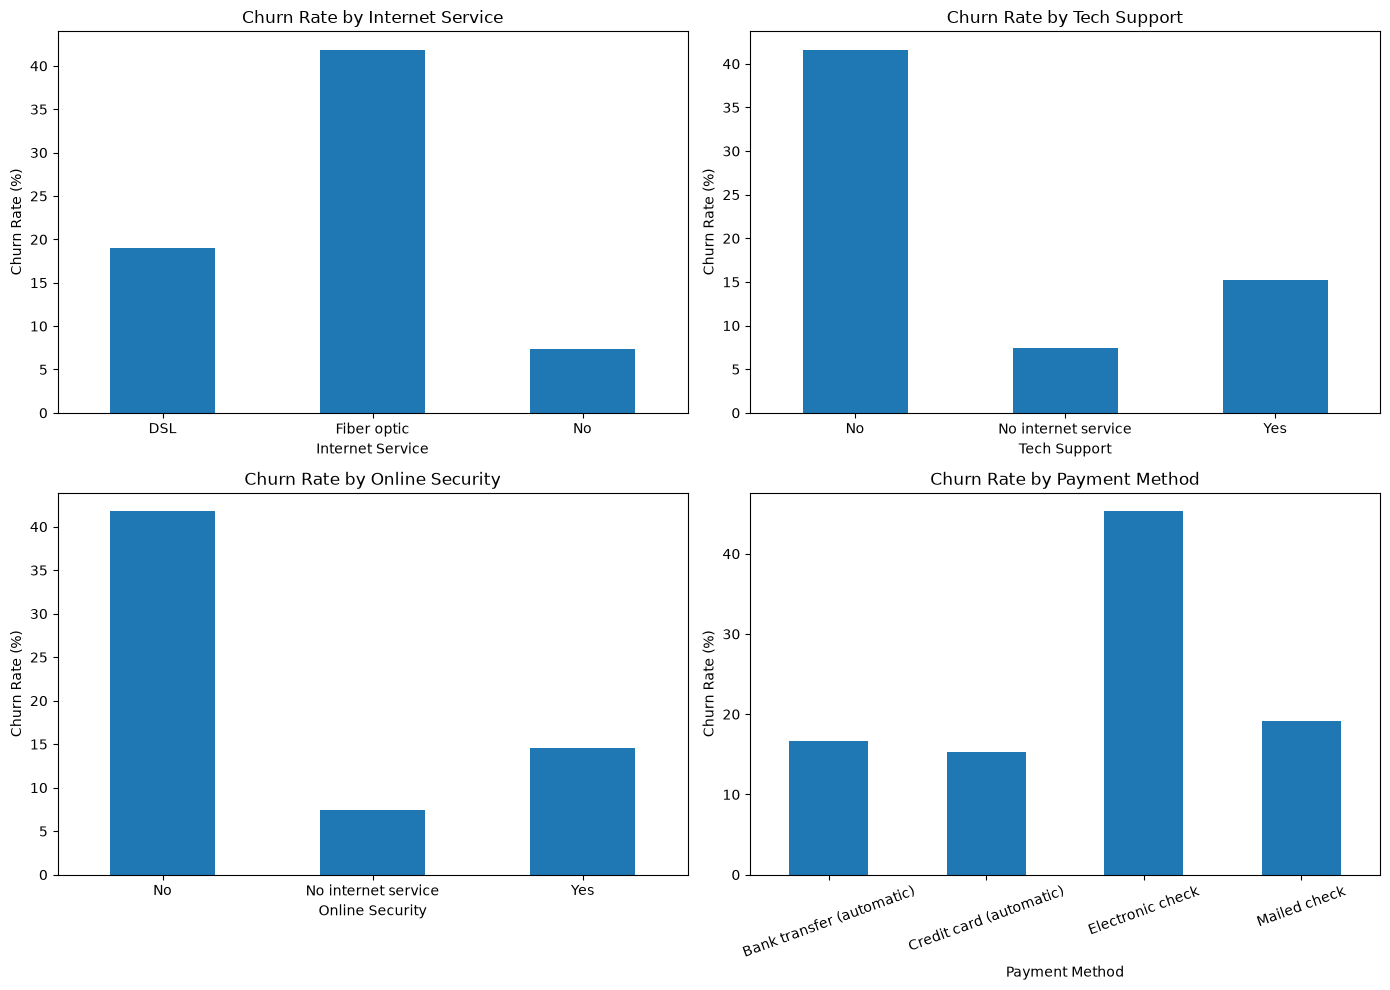

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

internet_churn.plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Churn Rate by Internet Service")
axes[0, 0].set_xlabel("Internet Service")
axes[0, 0].set_ylabel("Churn Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=0)

techsupport_churn.plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Churn Rate by Tech Support")
axes[0, 1].set_xlabel("Tech Support")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=0)

security_churn.plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Churn Rate by Online Security")
axes[1, 0].set_xlabel("Online Security")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=0)

payment_churn.plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Churn Rate by Payment Method")
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [61]:
revenue_at_risk = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].sum()

print(f"Monthly Revenue at Risk: {revenue_at_risk:,.2f}")

Monthly Revenue at Risk: 139,130.85


In [62]:
print(f"Monthly Revenue at Risk: {revenue_at_risk:,.2f}")

Monthly Revenue at Risk: 139,130.85


# Key Insights

### 1. Early-tenure customers are the highest-risk segment
Customers with 0–6 months of tenure have a 52.94% churn rate, compared with only 9.51% for customers with 49–72 months of tenure.

### 2. Contract type is strongly associated with churn
Month-to-month customers have a 42.71% churn rate, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

### 3. Electronic-check customers have high observed churn
Customers using electronic checks have a 45.29% churn rate, substantially higher than customers using automatic payment methods.

### 4. Service and support factors show strong churn differences
Fiber-optic customers have 41.89% churn, while customers without Tech Support and Online Security have churn rates of 41.64% and 41.77%, respectively.

### 5. Churn has financial implications
Customers who churned represented 139,130.85 in monthly recurring charges based on their recorded MonthlyCharges.

# Recommended Actions

- Strengthen onboarding and engagement during the first 6 months.
- Encourage suitable month-to-month customers to consider longer-term contracts.
- Investigate the electronic-check payment experience and promote automatic payment options.
- Promote Tech Support and Online Security services to relevant customers.
- Investigate the high churn observed among fiber-optic customers, including pricing, service quality, and support experience.



In [67]:
df.to_csv(
    "../data/processed/customer_churn_cleaned.csv",
    index=False
)